# Since 1930 — distribution shift in the Class A match table

This notebook is **exploratory**: it asks whether **labels** and **prematch numeric features** look similar across World Cup eras, using `data/processed/class_a_match_level.parquet` from notebook `01`.

**Why it exists:** Notebook `02` models recent men’s tournaments with LOTO. If early decades look nothing like 1998–2022, pooling or comparing coefficients across all years is harder to justify. This file quantifies **how large** those gaps are (not causal attribution).

**Main comparisons (men’s tournaments, even calendar years in this extract):**
- **Early:** 1930–1966 (smaller tournaments, fewer matches per edition).
- **Middle:** 1970–1994 (includes 24-team format from 1982).
- **Recent:** 1998–2022 (32-team format).

**Methods (short):** two-sample **Kolmogorov–Smirnov** tests on each numeric feature (**early vs recent**), plus **standardized mean differences** and simple plots. *p*-values are **multiple-testing heavy** (~one test per feature); we report a **Bonferroni** threshold as a conservative guide.

**Women’s World Cups** in this database use **odd** years (1991–2019). A short section shows **label** rates over **all** rows so the full 1930–2022 timeline is visible; feature-drift tests focus on **men’s** rows only so we do not mix two different competitions.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats


def repo_root() -> Path:
    """Project root (folder that contains ``notebooks/``)."""
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "notebooks").is_dir() and (candidate / "README.md").is_file():
            return candidate
    if p.name == "eda_worldcup":
        return p.parent.parent
    if p.name == "notebooks":
        return p.parent
    return p


REPO_ROOT = repo_root()
DATA_PATH = REPO_ROOT / "data" / "processed" / "class_a_match_level.parquet"
if not DATA_PATH.is_file():
    DATA_PATH = REPO_ROOT / "data" / "processed" / "class_a_match_level.csv"

assert DATA_PATH.is_file(), f"Run notebook 01 first: {DATA_PATH}"

df = (
    pd.read_parquet(DATA_PATH)
    if DATA_PATH.suffix == ".parquet"
    else pd.read_csv(DATA_PATH)
)
print("Shape:", df.shape, "| years:", int(df["year"].min()), "–", int(df["year"].max()))
print("Distinct tournament years:", df["year"].nunique())

Shape: (1248, 104) | years: 1930 – 2022
Distinct tournament years: 30


## 1) Men’s vs women’s rows in this extract

In `worldcup.db`, **men’s** finals tournaments appear on **even** years here; **women’s** on **odd** years. We add `is_mens_year = (year % 2 == 0)` for filtering.


In [2]:
df = df.copy()
df["is_mens_year"] = df["year"] % 2 == 0

vc = (
    df.groupby("is_mens_year")
    .agg(n_rows=("match_id", "count"), n_tournaments=("year", "nunique"))
    .rename(index={True: "men (even years)", False: "women (odd years)"})
)
display(vc)

men = df.loc[df["is_mens_year"]].copy()
print("Men’s row count:", len(men))

,n_rows,n_tournaments
is_mens_year,,
women (odd years),284,8
men (even years),964,22


Men’s row count: 964


## 2) Era buckets (men’s tournaments only)

| Era | Years | Rough context |
|-----|-------|----------------|
| Early | 1930–1966 | Fewer teams/matches per edition |
| Middle | 1970–1994 | Expansion; 24 teams from 1982 |
| Recent | 1998–2022 | 32-team format |


In [3]:
def era_men(y: int) -> str:
    if y <= 1966:
        return "early (1930–1966)"
    if y <= 1994:
        return "middle (1970–1994)"
    return "recent (1998–2022)"


men["era"] = men["year"].map(era_men)

display(
    men.groupby("era").agg(n_matches=("match_id", "count"), n_cups=("year", "nunique"))
)
display(
    men.groupby(["era", "year"])
    .size()
    .to_frame("n")
    .reset_index()
    .sort_values(["era", "year"])
)

,n_matches,n_cups
era,,
early (1930–1966),200,8
middle (1970–1994),316,7
recent (1998–2022),448,7


,era,year,n
0,early (1930–1966),1930,18
1,early (1930–1966),1934,17
2,early (1930–1966),1938,18
3,early (1930–1966),1950,22
4,early (1930–1966),1954,26
5,early (1930–1966),1958,35
6,early (1930–1966),1962,32
7,early (1930–1966),1966,32
8,middle (1970–1994),1970,32
9,middle (1970–1994),1974,38


## 3) Label shift — home win rate (`y_win`)

`y_win` = 1 if the designated home team wins (0 = draw or away win). We expect **some** variation by year (format, strength balance, randomness). Large systematic gaps across eras motivate era-specific baselines or careful generalization claims.


,home_win_rate,count
era,,
early (1930–1966),0.850,200
middle (1970–1994),0.532,316
recent (1998–2022),0.462,448


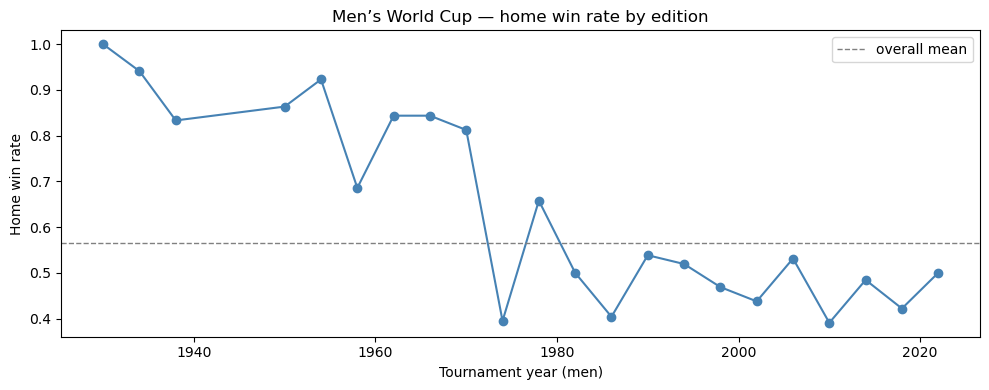

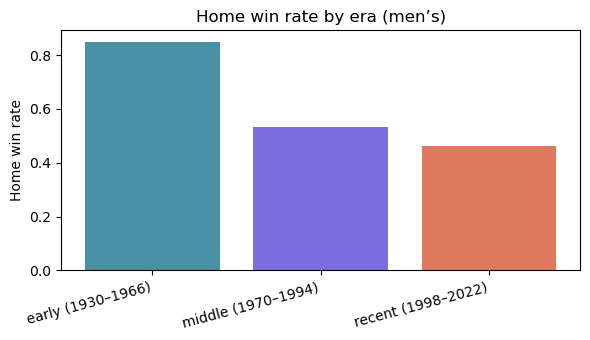

In [4]:
by_year = (
    men.groupby("year")["y_win"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "home_win_rate"})
)
by_era = (
    men.groupby("era")["y_win"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "home_win_rate"})
)

display(by_era.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_year.index, by_year["home_win_rate"], "o-", color="steelblue")
ax.axhline(men["y_win"].mean(), color="gray", ls="--", lw=1, label="overall mean")
ax.set_xlabel("Tournament year (men)")
ax.set_ylabel("Home win rate")
ax.set_title("Men’s World Cup — home win rate by edition")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 3.5))
order = ["early (1930–1966)", "middle (1970–1994)", "recent (1998–2022)"]
rates = [by_era.loc[e, "home_win_rate"] if e in by_era.index else np.nan for e in order]
ax.bar(order, rates, color=["#4a90a4", "#7b6ee0", "#e07a5f"])
ax.set_ylabel("Home win rate")
ax.set_title("Home win rate by era (men’s)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 4) Covariate shift — numeric features (early vs recent men’s)

We compare the **distribution** of each prematch numeric column between **early** and **recent** men’s rows (excluding IDs, labels, and string fields — same spirit as notebook `02`).

For each feature we run `scipy.stats.ks_2samp` on pairwise complete observations. The **KS statistic** lies in [0, 1]; larger = more separation between empirical CDFs.

**Excluded from KS:** `home_squad_year` and `away_squad_year` are copies of the tournament edition year (see notebook `01`); comparing early vs recent eras would trivially give KS ≈ 1, so they are dropped here.

**Bonferroni:** with \(m\) features, a conservative family-wise threshold is \(0.05/m\).


In [5]:
id_cols = ["match_id", "tournament_id", "home_team_id", "away_team_id"]
non_feature = set(
    id_cols
    + [
        "y_win",
        "stage_name",
        "group_name",
        "year",
        "is_mens_year",
        "era",
        "home_squad_year",
        "away_squad_year",
    ]
)

num_cols = [
    c
    for c in men.columns
    if c not in non_feature and pd.api.types.is_numeric_dtype(men[c])
]
num_cols = sorted(num_cols)
print(len(num_cols), "numeric columns tested")

early = men["era"] == "early (1930–1966)"
recent = men["era"] == "recent (1998–2022)"

rows = []
for col in num_cols:
    a = men.loc[early, col].dropna().astype(float)
    b = men.loc[recent, col].dropna().astype(float)
    if len(a) < 10 or len(b) < 10:
        continue
    res = stats.ks_2samp(a, b)
    ma, mb = float(a.mean()), float(b.mean())
    sa, sb = float(a.std(ddof=1)), float(b.std(ddof=1))
    pooled = np.sqrt((sa**2 + sb**2) / 2) if (sa + sb) > 0 else np.nan
    cohen_d = (mb - ma) / pooled if pooled and pooled > 0 else np.nan
    rows.append(
        {
            "feature": col,
            "ks_statistic": float(res.statistic),
            "p_value": float(res.pvalue),
            "mean_early": ma,
            "mean_recent": mb,
            "cohen_d_recent_minus_early": (
                float(cohen_d) if cohen_d == cohen_d else np.nan
            ),
            "n_early": int(len(a)),
            "n_recent": int(len(b)),
        }
    )

ks_df = (
    pd.DataFrame(rows)
    .sort_values("ks_statistic", ascending=False)
    .reset_index(drop=True)
)
m = len(ks_df)
alpha = 0.05
ks_df["reject_bonferroni"] = ks_df["p_value"] < (alpha / max(m, 1))
ks_df["bonferroni_alpha"] = alpha / max(m, 1)

print(f"Features tested: {m} | Bonferroni alpha: {alpha/m:.2e}")
print("Top 20 by KS statistic (early vs recent, men’s):")
display(
    ks_df.head(20)[
        [
            "feature",
            "ks_statistic",
            "p_value",
            "reject_bonferroni",
            "cohen_d_recent_minus_early",
            "mean_early",
            "mean_recent",
        ]
    ].round(4)
)

94 numeric columns tested
Features tested: 92 | Bonferroni alpha: 5.43e-04
Top 20 by KS statistic (early vs recent, men’s):


,feature,ks_statistic,p_value,reject_bonferroni,cohen_d_recent_minus_early,mean_early,mean_recent
0,home_squad_n_players,0.8466,0.0,True,1.2817,21.7200,23.2879
1,away_squad_n_players,0.8444,0.0,True,1.3118,21.4900,23.2835
2,home_squad_n_fw,0.7839,0.0,True,-2.3558,8.4750,5.1987
3,home_hist_losses,0.7813,0.0,True,1.8834,2.3550,13.7433
4,away_squad_n_fw,0.7706,0.0,True,-2.3897,8.6600,5.2433
5,home_hist_n_tournaments,0.6578,0.0,True,1.5700,2.0050,9.3616
6,home_hist_n_matches,0.6537,0.0,True,1.4667,6.8250,39.7946
7,away_hist_losses,0.6146,0.0,True,1.4988,2.3150,11.7701
8,home_squad_n_df,0.6074,0.0,True,1.4878,5.7600,7.8080
9,home_hist_draws,0.5976,0.0,True,1.5502,0.9350,6.3549


## 5) Visual checks

**Left:** largest KS features (names truncated). **Right:** ECDF overlap for one illustrative variable (`home_hist_win_rate_shrunk`) — early vs recent.


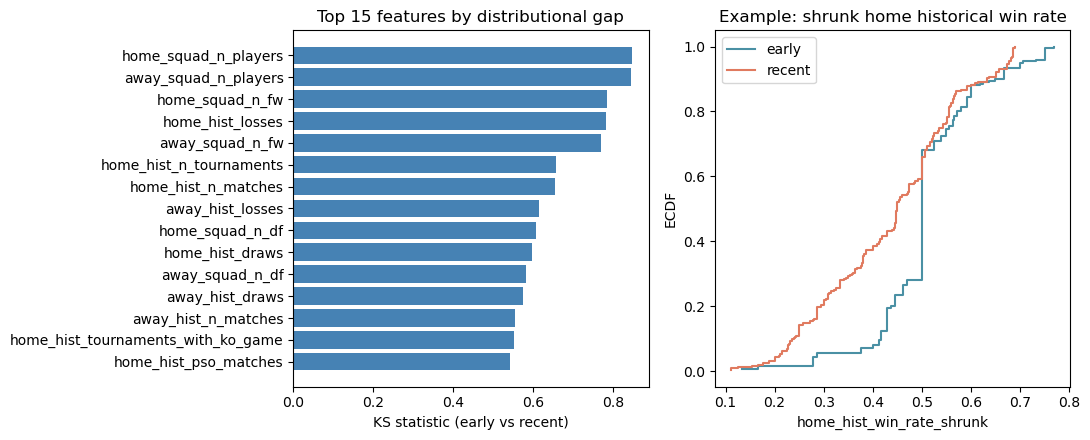

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

topn = min(15, len(ks_df))
sub = ks_df.head(topn).iloc[::-1]
labels = [f[:40] + "…" if len(f) > 40 else f for f in sub["feature"]]
axes[0].barh(labels, sub["ks_statistic"], color="steelblue")
axes[0].set_xlabel("KS statistic (early vs recent)")
axes[0].set_title(f"Top {topn} features by distributional gap")

col_demo = "home_hist_win_rate_shrunk"
if col_demo in men.columns:
    a = men.loc[early, col_demo].dropna().astype(float)
    b = men.loc[recent, col_demo].dropna().astype(float)
    for data, name, c in [(a, "early", "#4a90a4"), (b, "recent", "#e07a5f")]:
        x = np.sort(data)
        y = np.arange(1, len(x) + 1) / len(x)
        axes[1].step(x, y, where="post", label=name, color=c)
    axes[1].set_xlabel(col_demo)
    axes[1].set_ylabel("ECDF")
    axes[1].legend()
    axes[1].set_title("Example: shrunk home historical win rate")
else:
    axes[1].text(0.5, 0.5, "Column missing", ha="center")

plt.tight_layout()
plt.show()

## 6) Full sample timeline — `y_win` by year (men + women)

Odd years are **women’s** tournaments in this extract; rates are **not** comparable to men’s for the same `y_win` definition without further context. The plot is useful mainly to see **coverage** and **coarse** label movement across the full table.


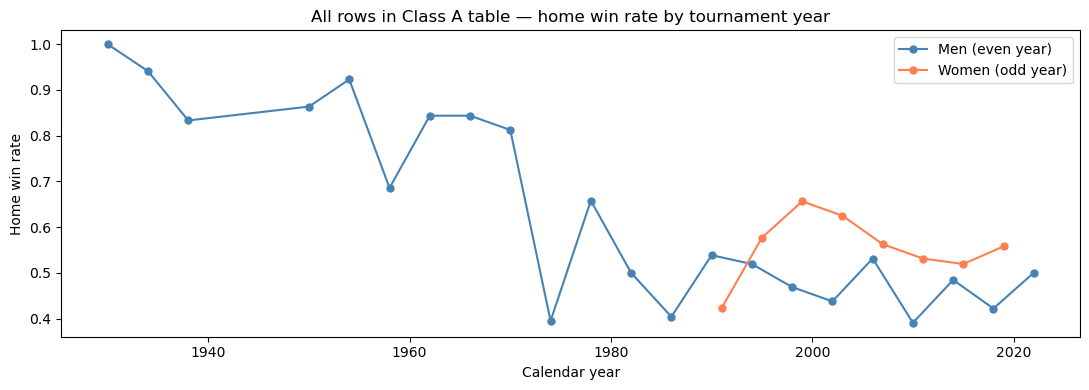

,year,home_win_rate,n,mens
0,1930,1.000,18,True
1,1934,0.941,17,True
2,1938,0.833,18,True
3,1950,0.864,22,True
4,1954,0.923,26,True
5,1958,0.686,35,True
6,1962,0.844,32,True
7,1966,0.844,32,True
8,1970,0.812,32,True
9,1974,0.395,38,True


In [7]:
all_y = (
    df.groupby("year")
    .agg(
        home_win_rate=("y_win", "mean"),
        n=("y_win", "count"),
        mens=("is_mens_year", "first"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 4))
for flag, sub, color, lab in [
    (True, all_y[all_y["mens"]], "steelblue", "Men (even year)"),
    (False, all_y[~all_y["mens"]], "coral", "Women (odd year)"),
]:
    ax.plot(sub["year"], sub["home_win_rate"], "o-", color=color, label=lab, ms=5)
ax.set_xlabel("Calendar year")
ax.set_ylabel("Home win rate")
ax.set_title("All rows in Class A table — home win rate by tournament year")
ax.legend()
plt.tight_layout()
plt.show()

display(all_y.round(3))

## 7) Short takeaways (read with the caveats above)

- **Era buckets** are a coarse stand-in for format and data-quality changes; they are not the only defensible split.
- **Label shift:** a very high early-era `y_win` rate often reflects **small samples**, older tournament formats, and how “home” was assigned in the database — not necessarily a stable “85% home advantage” to extrapolate. Treat early bucket rates as **descriptive**.
- **KS *p*-values** are univariate and **not** independent across related columns (many `home_*` / `away_*` pairs move together). Bonferroni is **very conservative**; large KS with “non-significant” *p* after correction can still indicate **practical** shift worth a plot.
- **Historical count features** (`*_hist_wins`, `*_hist_n_matches`, …) almost **must** differ early vs recent: modern teams have had more editions to accumulate appearances in the DB. That is **expected drift**, not necessarily a surprise finding.
- **Early vs recent** is the starkest contrast; **middle** often sits between the two — you can extend the same code to `middle vs recent` if needed.
- For modeling narratives, notebook `02` stays on **recent men’s** LOTO; this notebook supports the **motivation** for not blindly pooling 1930–2022 in one i.i.d. bag.
